# Análisis de Datos II — Actividad 4: Feature engineering, data leakage, auditoría de sesgos y documentación

**Dataset:** `census_income.csv`. El objetivo es predecir el ingreso anual de cada persona (`income`) a partir de sus características.

## 1. Carga y descripción del dataset

In [1]:
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

In [2]:
DATA_PATH = Path("data/census_income.csv")
DATA_URL = "https://drive.usercontent.google.com/download?id=1Od_naN-d1B_mjJeIMDlL1dTvHEDX9PO6&export=download&confirm=t"

if not DATA_PATH.exists():
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

df = pd.read_csv(DATA_PATH)
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()

Filas: 10000  |  Columnas: 9


,age,hours_per_week,education,employer_type,marital_status,sex,race,born_in_us,income
0,55,55.0,Graduate degree,Self-employed (incorporated),Divorced,Male,White,Yes,279000.0
1,20,35.0,High school,Private,Never married,Female,White,Yes,23000.0
2,59,30.0,High school,State government,Divorced,Female,White,Yes,15100.0
3,43,40.0,Some college,State government,Married,Male,Black,Yes,31200.0
4,33,20.0,No high school diploma,Private,Married,Female,Black,Yes,9400.0


| Variable | Tipo | Descripción |
|---|---|---|
| `age` | numérica | Edad |
| `hours_per_week` | numérica | Horas trabajadas por semana |
| `education` | categórica | Máximo nivel educativo alcanzado |
| `employer_type` | categórica | Tipo de empleador |
| `marital_status` | categórica | Estado civil |
| `sex` | categórica (sensible) | Sexo |
| `race` | categórica (sensible) | Raza |
| `born_in_us` | categórica | Si nació en EE. UU. |
| `income` | numérica (**target**) | Ingreso anual en USD |

In [3]:
NUM = ["age", "hours_per_week"]
CAT = ["education", "employer_type", "marital_status", "sex", "race", "born_in_us"]
TARGET = "income"

pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "faltantes": df.isna().sum(),
    "% faltantes": (df.isna().mean() * 100).round(1),
    "valores distintos": df.nunique(),
})

,tipo,faltantes,% faltantes,valores distintos
age,int64,0,0.0,73
hours_per_week,float64,500,5.0,80
education,object,300,3.0,6
employer_type,object,400,4.0,8
marital_status,object,0,0.0,5
sex,object,0,0.0,2
race,object,0,0.0,4
born_in_us,object,0,0.0,2
income,float64,0,0.0,1365


In [4]:
dup = df[df.duplicated(keep=False)]
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")
print(f"Edad mediana de las filas duplicadas: {dup['age'].median():.0f}  (dataset: {df['age'].median():.0f})")
dup.sort_values(list(df.columns)).head(6)

Filas duplicadas exactas: 86
Edad mediana de las filas duplicadas: 24  (dataset: 43)


,age,hours_per_week,education,employer_type,marital_status,sex,race,born_in_us,income
1044,17,15.0,No high school diploma,Private,Never married,Male,White,Yes,2000.0
8026,17,15.0,No high school diploma,Private,Never married,Male,White,Yes,2000.0
1706,17,20.0,No high school diploma,Private,Never married,Female,White,Yes,400.0
5853,17,20.0,No high school diploma,Private,Never married,Female,White,Yes,400.0
4334,17,20.0,No high school diploma,Private,Never married,Male,White,Yes,800.0
8965,17,20.0,No high school diploma,Private,Never married,Male,White,Yes,800.0


**OBSERVACIONES**
- Hay faltantes en `hours_per_week` (5%), `employer_type` (4%) y `education` (3%). Se imputan **dentro del pipeline** del modelo para que el valor imputado se calcule solo con datos de entrenamiento.
- Las 86 filas duplicadas corresponden a perfiles muy frecuentes (sobre todo adolescentes con pocas horas y sin secundario completo) con ingresos redondos. Con 8 variables de baja granularidad es esperable que dos personas distintas coincidan, por lo que se conservan.

In [5]:
import matplotlib.pyplot as plt

# Tokens de superficie/texto y colores de serie, igual que en las actividades anteriores.
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9"
C_MAIN, C_2 = "#2a78d6", "#eb6834"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})

## 2. Parte 1: feature engineering y prevención de data leakage

### 2.a Distribución de la target

Se compara la distribución original con las transformaciones *log*, *Box-Cox* y *Yeo-Johnson*. Como `income` es estrictamente positivo, las tres son aplicables.

> Acá las transformaciones se ajustan sobre todo el dataset solo con fines exploratorios. En el modelo, el parámetro λ se vuelve a estimar en cada fold usando únicamente los datos de entrenamiento.

In [6]:
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer

y = df[TARGET]
print(f"income: min {y.min():,.0f}  |  mediana {y.median():,.0f}  |  media {y.mean():,.0f}  |  max {y.max():,.0f}")

transformaciones = {"original": (y.values, None), "log": (np.log(y.values), None)}
for metodo in ["box-cox", "yeo-johnson"]:
    pt = PowerTransformer(method=metodo).fit(y.to_frame())
    transformaciones[metodo] = (pt.transform(y.to_frame()).ravel(), pt.lambdas_[0])

pd.DataFrame({
    nombre: {"skewness": skew(v), "lambda": lam}
    for nombre, (v, lam) in transformaciones.items()
}).T.round(3)

income: min 110  |  mediana 36,400  |  media 54,407  |  max 1,096,000


,skewness,lambda
original,4.453,NaN
log,-1.011,NaN
box-cox,0.055,0.214
yeo-johnson,0.055,0.214


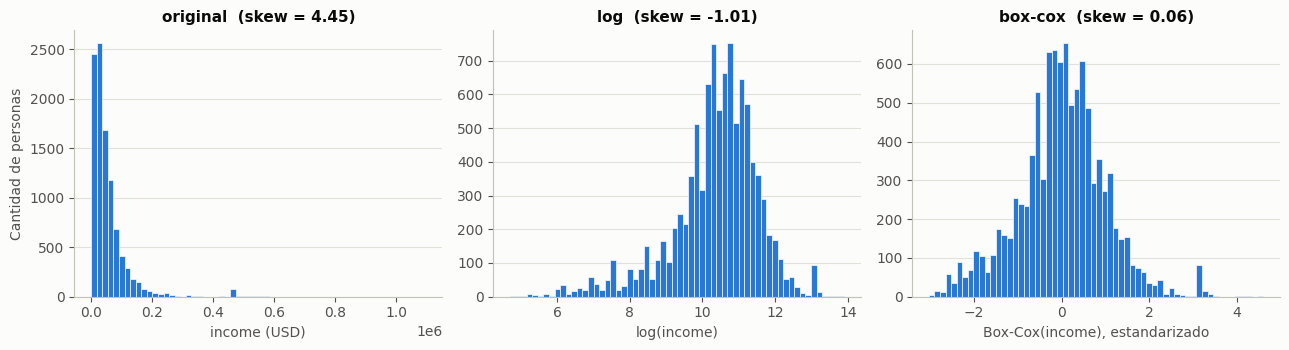

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, nombre in zip(axes, ["original", "log", "box-cox"]):
    v = transformaciones[nombre][0]
    ax.hist(v, bins=60, color=C_MAIN, edgecolor=SURFACE, linewidth=0.5)
    ax.set_title(f"{nombre}  (skew = {skew(v):.2f})")
    ax.grid(axis="y")
    ax.set_axisbelow(True)
axes[0].set_xlabel("income (USD)")
axes[1].set_xlabel("log(income)")
axes[2].set_xlabel("Box-Cox(income), estandarizado")
axes[0].set_ylabel("Cantidad de personas")
plt.tight_layout()
plt.show()

**OBSERVACIONES**
- La target original tiene una **asimetría positiva muy fuerte** (skew 4,45): la mediana (36.400) está muy por debajo de la media (54.400) y hay una cola larga hasta 1,1 millones. Se ve además un pico aislado en 471.000 USD. Una regresión lineal ajustada por mínimos cuadrados sobre esta escala posiblemente quede dominada por los pocos ingresos muy altos.
- **Log** sobrecorrige: la cola derecha desaparece pero aparece una cola izquierda (skew −1,01) generada por los ingresos muy bajos (mínimo 110 USD, 1% por debajo de 600 USD), que en escala logarítmica quedan muy lejos del resto.
- **Box-Cox** estima λ ≈ 0,21 (intermedio entre log, λ = 0, y raíz cuadrada, λ = 0,5) y deja la distribución prácticamente simétrica (skew 0,06). **Yeo-Johnson** da el mismo resultado porque no hay valores ≤ 0.
- Se elige **Box-Cox**: es la que mejor simetriza la target, es aplicable porque `income > 0` y su λ se estima a partir de los datos, por lo que se puede reajustar en cada fold.

### 2.b Regresión lineal con k-fold cross validation sin data leakage

#### Feature engineering de las variables numéricas

Antes de armar el modelo se mira cómo se relaciona el ingreso con las dos variables numéricas.

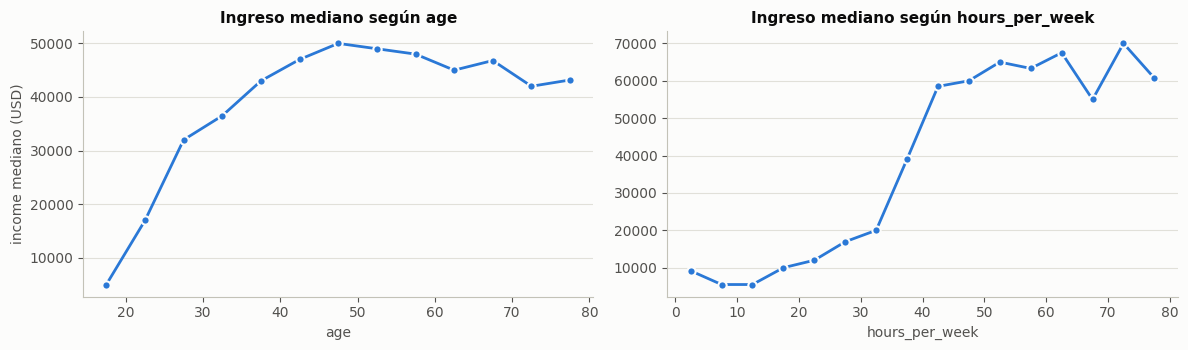

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, col, bins in [(axes[0], "age", range(15, 95, 5)), (axes[1], "hours_per_week", range(0, 105, 5))]:
    tramos = pd.cut(df[col], bins=list(bins))
    med = df.groupby(tramos, observed=True)[TARGET].median()
    n = df.groupby(tramos, observed=True)[TARGET].size()
    med = med[n >= 30]  # se omiten tramos con pocas observaciones
    x = [i.mid for i in med.index]
    ax.plot(x, med.values, color=C_MAIN, linewidth=2, marker="o", markersize=6,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.set_title(f"Ingreso mediano según {col}")
    ax.set_xlabel(col)
    ax.grid(axis="y")
    ax.set_axisbelow(True)
axes[0].set_ylabel("income mediano (USD)")
plt.tight_layout()
plt.show()

**OBSERVACIONES**
- La relación con la **edad**: el ingreso crece rápido hasta los 45-50 años y cae levemente después. Un único coeficiente lineal no puede representar esa forma. Para aproximarse, al menos 2 rectas.
- Con las **horas trabajadas** el ingreso es bajo y casi constante hasta las 30 h, salta entre las 30 y las 45 h (paso de jornada parcial a completa) y luego se aplana.
- Por eso, las dos variables numéricas se expanden con **splines cúbicos** (`SplineTransformer`, 5 nodos), que permiten a la regresión lineal ajustar una curva suave por variable sin dejar de ser un modelo lineal en sus parámetros.

#### Pipeline y fuentes de leakage

Todo paso que **aprende algo de los datos** debe ajustarse solo con el fold de entrenamiento. En este problema hay cuatro:

| Paso | Qué aprende de los datos | Riesgo si se ajusta antes del split |
|---|---|---|
| Imputación numérica (`SimpleImputer`, mediana) | mediana de `hours_per_week` | la mediana incluye a las filas de testeo |
| Splines (`SplineTransformer`) | ubicación de los nodos (rango de cada variable) | los nodos se ubican usando el rango de testeo |
| One-hot (`OneHotEncoder`) | categorías existentes | se conocen categorías que solo aparecen en testeo |
| Transformación de la target (`PowerTransformer`, Box-Cox) | λ, media y desvío de la target transformada | **la target de testeo participa del ajuste** |

Los faltantes categóricos se imputan con una categoría propia (`"Desconocido"`) en lugar de la moda, para no asumir que una persona sin dato pertenece al grupo más frecuente.

Se encapsula todo en un `Pipeline` y la transformación de la target en un `TransformedTargetRegressor`. Así, `cross_validate` vuelve a ajustar cada paso en cada fold y la validación se hace siempre sobre datos no vistos.

In [9]:
from sklearn.compose import TransformedTargetRegressor, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer

X = df[NUM + CAT]
y = df[TARGET]


def armar_modelo(target="box-cox"):
    """Pipeline completo; target: 'original', 'log' o 'box-cox'."""
    preprocesamiento = make_column_transformer(
        (make_pipeline(SimpleImputer(strategy="median"), SplineTransformer(n_knots=5, degree=3)), NUM),
        (make_pipeline(SimpleImputer(strategy="constant", fill_value="Desconocido"),
                       OneHotEncoder(drop="first", handle_unknown="ignore")), CAT),
    )
    regresor = {
        "original": LinearRegression(),
        "log": TransformedTargetRegressor(LinearRegression(), func=np.log, inverse_func=np.exp),
        "box-cox": TransformedTargetRegressor(LinearRegression(), transformer=PowerTransformer(method="box-cox")),
    }[target]
    return make_pipeline(preprocesamiento, regresor)


CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
armar_modelo()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('transformedtargetregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sp

Se verifica que cada fold aprende sus propios parámetros: si hubiera leakage (por ejemplo, transformar la target antes de partir los datos), λ y la mediana imputada serían idénticos en todos los folds.

In [10]:
res = cross_validate(armar_modelo("box-cox"), X, y, cv=CV, scoring="neg_mean_absolute_error", return_estimator=True)

pd.DataFrame({
    "n_train": [len(tr) for tr, _ in CV.split(X)],
    "n_valid": [len(va) for _, va in CV.split(X)],
    "lambda Box-Cox": [m[-1].transformer_.lambdas_[0] for m in res["estimator"]],
    "mediana imputada hours_per_week": [m[0].named_transformers_["pipeline-1"][0].statistics_[1] for m in res["estimator"]],
    "MAE validación": -res["test_score"],
}, index=[f"fold {i + 1}" for i in range(CV.n_splits)]).round(4)

,n_train,n_valid,lambda Box-Cox,mediana imputada hours_per_week,MAE validación
fold 1,8000,2000,0.2110,40.0,25876.7224
fold 2,8000,2000,0.2155,40.0,27093.6890
fold 3,8000,2000,0.2132,40.0,26953.9200
fold 4,8000,2000,0.2115,40.0,25799.9886
fold 5,8000,2000,0.2194,40.0,27994.2717


**OBSERVACIONES**
- λ cambia levemente entre folds (≈ 0,21-0,22): cada uno se estima solo con el 80% de entrenamiento y el fold de validación no participa. La mediana imputada coincide (40 h) porque es un valor muy frecuente, pero también se calcula solo con el fold de entrenamiento.
- El MAE es estable entre folds, por lo que el promedio es una estimación confiable del error fuera de muestra.

### 2.c MAE con la target original vs. transformada

Se entrena el mismo pipeline con tres variantes de target y se evalúan con los mismos 5 folds. Las predicciones de los modelos transformados se **vuelven a la escala original** (USD) antes de calcular el error, así los MAE son comparables. Se incluye log como referencia.

In [11]:
filas = {}
for target in ["original", "log", "box-cox"]:
    modelo = armar_modelo(target)
    r = cross_validate(modelo, X, y, cv=CV,
                       scoring=["neg_mean_absolute_error", "neg_median_absolute_error", "r2"])
    pred = cross_val_predict(modelo, X, y, cv=CV)  # prediccion fuera de muestra para cada fila
    filas[target] = {
        "MAE": -r["test_neg_mean_absolute_error"].mean(),
        "MAE (desvío entre folds)": r["test_neg_mean_absolute_error"].std(),
        "MedAE": -r["test_neg_median_absolute_error"].mean(),
        "R²": r["test_r2"].mean(),
        "% predicciones negativas": (pred < 0).mean() * 100,
        "predicción media": pred.mean(),
    }

comparacion = pd.DataFrame(filas).T
print(f"income real: media {y.mean():,.0f}  |  mediana {y.median():,.0f}")
comparacion.round(3)

income real: media 54,407  |  mediana 36,400


,MAE,MAE (desvío entre folds),MedAE,R²,% predicciones negativas,predicción media
original,30804.930,680.176,19610.320,0.277,5.98,54398.877
log,26970.901,843.890,13045.641,0.250,0.00,42027.820
box-cox,26743.718,821.323,13474.378,0.266,0.00,44186.154


**OBSERVACIONES**
- Con la target **Box-Cox el MAE baja de ≈ 30.800 a ≈ 26.700 USD (−13%)** y el error mediano de ≈ 19.600 a ≈ 13.500 USD. El modelo original, además, genera un **6% de predicciones negativas**, imposibles para un ingreso; los modelos transformados no pueden hacerlo porque la transformación inversa siempre devuelve valores positivos.
- El **R² es algo menor** con Box-Cox. No es contradictorio: el R² premia acertar a la media (minimiza el error cuadrático), mientras que un modelo ajustado en escala transformada y vuelto a USD estima aproximadamente la **mediana condicional**, que es justamente lo que minimiza el error absoluto.
- Consecuencia práctica de lo anterior: la predicción media con Box-Cox (≈ 44.200) queda **por debajo del ingreso medio real** (54.400). El modelo es mejor para estimar el ingreso de una persona típica, pero **subestima sumas o promedios** de grupos de personas (sesgo de retransformación).
- Log queda muy cerca de Box-Cox en MAE y MedAE, pero con menor R² y una predicción media más baja: al estirar la cola izquierda (2.a), los ingresos muy bajos pesan más en el ajuste y empujan las predicciones hacia abajo. Box-Cox ofrece el mejor balance.

**Modelo final:** regresión lineal con splines en las variables numéricas, one-hot en las categóricas y **target Box-Cox**.

## 3. Parte 2: auditoría de sesgos y documentación

### 3.a Rendimiento por subgrupo

Se evalúan `sex` y `race` usando las **predicciones fuera de muestra** del modelo final (`cross_val_predict`): cada persona es predicha por un modelo que no la vio durante el entrenamiento.

Métricas por subgrupo:
- **MAE**: error absoluto medio en USD.
- **MAE relativo**: MAE / ingreso medio del grupo. Como el error crece con el nivel de ingreso, permite comparar grupos con ingresos distintos.
- **Error medio** (predicción − real) y **% subestimados**: dirección del error; si un grupo es sistemáticamente sub o sobreestimado.

In [12]:
modelo_final = armar_modelo("box-cox")
pred_oof = cross_val_predict(modelo_final, X, y, cv=CV)
aud = df.assign(pred=pred_oof, error=pred_oof - y, error_abs=np.abs(pred_oof - y))


def metricas_por_grupo(col):
    g = aud.groupby(col)
    t = pd.DataFrame({
        "n": g.size(),
        "income medio": g[TARGET].mean(),
        "income mediano": g[TARGET].median(),
        "MAE": g["error_abs"].mean(),
        "MAE relativo": g["error_abs"].mean() / g[TARGET].mean(),
        "error medio": g["error"].mean(),
        "error medio relativo": g["error"].mean() / g[TARGET].mean(),
        "% subestimados": g.apply(lambda d: (d["pred"] < d[TARGET]).mean() * 100, include_groups=False),
    })
    t.loc["Global"] = [len(aud), y.mean(), y.median(), aud["error_abs"].mean(),
                       aud["error_abs"].mean() / y.mean(), aud["error"].mean(),
                       aud["error"].mean() / y.mean(), (aud["pred"] < y).mean() * 100]
    return t


por_sexo = metricas_por_grupo("sex")
por_raza = metricas_por_grupo("race")
por_sexo.round(3)

,n,income medio,income mediano,MAE,MAE relativo,error medio,error medio relativo,% subestimados
sex,,,,,,,,
Female,4864.0,43102.185,30000.0,20954.206,0.486,-6953.273,-0.161,51.830
Male,5136.0,65112.781,43550.0,32226.621,0.495,-13315.033,-0.204,49.805
Global,10000.0,54406.827,36400.0,26743.718,0.492,-10220.673,-0.188,50.790


In [13]:
por_raza.round(3)

,n,income medio,income mediano,MAE,MAE relativo,error medio,error medio relativo,% subestimados
race,,,,,,,,
Asian,432.0,62466.065,45000.0,30249.225,0.484,-12441.366,-0.199,51.620
Black,2341.0,39688.736,30000.0,18435.328,0.464,-5133.655,-0.129,51.773
Other or multiple,430.0,38446.605,28000.0,18054.275,0.470,-5417.754,-0.141,50.000
White,6797.0,59973.454,40000.0,29932.187,0.499,-12135.434,-0.202,50.449
Global,10000.0,54406.827,36400.0,26743.718,0.492,-10220.673,-0.188,50.790


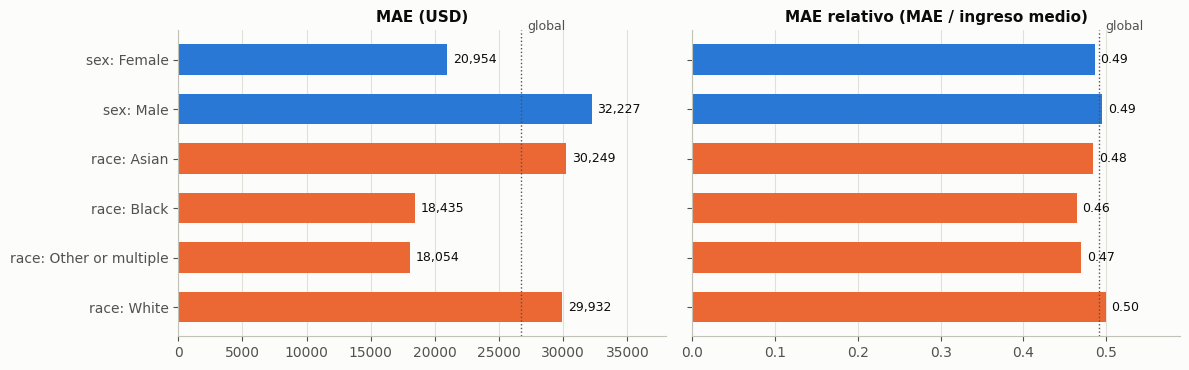

In [14]:
grupos = pd.concat([por_sexo.drop("Global"), por_raza.drop("Global")],
                   keys=["sex", "race"]).iloc[::-1]
etiquetas = [f"{v}: {g}" for v, g in grupos.index]
colores = [C_MAIN if v == "sex" else C_2 for v, _ in grupos.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, col, ref, fmt, titulo in [
    (axes[0], "MAE", por_sexo.loc["Global", "MAE"], "{:,.0f}", "MAE (USD)"),
    (axes[1], "MAE relativo", por_sexo.loc["Global", "MAE relativo"], "{:.2f}", "MAE relativo (MAE / ingreso medio)"),
]:
    ax.barh(etiquetas, grupos[col], color=colores, height=0.62)
    ax.axvline(ref, color=INK_2, linewidth=1, linestyle=":")
    ax.annotate("global", (ref, len(grupos) - 0.4), xytext=(4, 0), textcoords="offset points",
                color=INK_2, fontsize=9)
    for i, v in enumerate(grupos[col]):
        ax.annotate(fmt.format(v), (v, i), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=9, color=INK)
    ax.set_xlim(0, grupos[col].max() * 1.18)
    ax.set_title(titulo)
    ax.grid(axis="x")
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**OBSERVACIONES**
- **En USD hay disparidades grandes:** el MAE de los hombres (≈ 32.200) es un 54% mayor que el de las mujeres (≈ 21.000), y el de las personas blancas y asiáticas (≈ 30.000) es un 60-70% mayor que el de las personas negras u "Other or multiple" (≈ 18.000-18.400).
- **En términos relativos las diferencias casi desaparecen:** el MAE relativo queda entre 0,46 y 0,50 para todos los grupos. Las diferencias en USD se explican principalmente por el **nivel de ingreso de cada grupo** (los grupos con ingresos más altos y más dispersos tienen errores absolutos mayores), no por un peor ajuste del modelo a un grupo en particular.
- **Dirección del error:** todos los grupos son subestimados en promedio (sesgo de retransformación visto en 2.c) y en una proporción parecida (≈ 50-52% de subestimados). En términos relativos la subestimación es algo mayor para hombres (−20%) y personas blancas/asiáticas que para mujeres (−16%) y personas negras, porque esos grupos tienen más ingresos en la cola alta, que el modelo no alcanza.
- Los grupos **Asian** y **Other or multiple** tienen solo ≈ 430 personas cada uno: sus métricas son menos estables que las del resto.

#### Efecto directo de las variables sensibles

Que el error sea parejo no implica que el modelo sea neutral: `sex` y `race` son **entradas** del modelo, por lo que este puede reproducir las brechas de ingreso presentes en los datos. Para medirlo se hace una prueba contrafáctica: se entrena el modelo final con todos los datos, se cambia **solo** la variable sensible de cada persona (dejando el resto igual) y se compara la predicción.

In [15]:
modelo_final.fit(X, y)


def contrafactico(col, desde, hacia):
    filas = X[X[col] == desde]
    p_real = modelo_final.predict(filas)
    p_cf = modelo_final.predict(filas.assign(**{col: hacia}))
    return {"n": len(filas), "variación mediana de la predicción": np.median(p_cf / p_real - 1) * 100}


pd.DataFrame({
    f"{col}: {a} -> {b}": contrafactico(col, a, b)
    for col, a, b in [("sex", "Female", "Male"), ("race", "Black", "White"),
                      ("race", "Asian", "White"), ("race", "Other or multiple", "White")]
}).T.round(1)

,n,variación mediana de la predicción
sex: Female -> Male,4864.0,27.4
race: Black -> White,2341.0,16.9
race: Asian -> White,432.0,-0.7
race: Other or multiple -> White,430.0,4.9


**OBSERVACIONES**
- Con todo lo demás igual (edad, horas, educación, empleador, estado civil, origen), el modelo **predice un ingreso ≈ 27% mayor para una persona por el solo hecho de ser hombre**, y ≈ 17% mayor para una persona blanca que para una negra. Entre personas asiáticas y blancas prácticamente no hay diferencia (−1%).
- El modelo **aprende y reproduce las brechas históricas** de ingreso por sexo y raza presentes en los datos. Para describir la realidad del censo esto es correcto, pero si el modelo se usara para **tomar decisiones** sobre personas (créditos, salarios ofrecidos, elegibilidad para beneficios), trasladaría esa brecha a la decisión. En ese caso habría que evaluar quitar las variables sensibles y revisar variables que actúen como proxy (por ejemplo, `marital_status` o `employer_type`).

### 3.b Model Card

| | |
|---|---|
| **Modelo** | Regresión lineal (`LinearRegression`) sobre target transformada con Box-Cox, dentro de un `Pipeline` de scikit-learn. |
| **Propósito** | Estimar el ingreso anual **típico** (aproximadamente la mediana condicional) de una persona a partir de características demográficas y laborales. |
| **Usos no previstos** | Decisiones individuales sobre personas (créditos, contratación, salarios, beneficios), estimación de ingresos totales o promedios de una población. |
| **Datos** | `census_income.csv`: 10.000 personas de EE. UU., 8 variables de entrada. Faltantes en `hours_per_week` (5%), `employer_type` (4%) y `education` (3%). |
| **Entradas** | Numéricas: `age`, `hours_per_week` (imputación por mediana + splines cúbicos). Categóricas: `education`, `employer_type`, `marital_status`, `sex`, `race`, `born_in_us` (imputación con categoría `"Desconocido"` + one-hot). |
| **Salida** | `income` estimado en USD anuales (siempre positivo). |
| **Evaluación** | 5-fold cross validation (shuffle, `random_state=42`); todos los pasos de preprocesamiento y la transformación de la target se reajustan en cada fold. |

**Desempeño global (cross validation)**

| Métrica | Modelo final (Box-Cox) | Referencia: target original |
|---|---|---|
| MAE | ≈ 26.700 USD | ≈ 30.800 USD |
| MAE relativo (MAE / ingreso medio) | 0,49 | 0,57 |
| Error absoluto mediano | ≈ 13.500 USD | ≈ 19.600 USD |
| R² | 0,27 | 0,28 |
| Predicciones negativas | 0% | 6% |

**Desempeño por subgrupo (predicciones fuera de muestra)**

| Grupo | n | Ingreso medio | MAE | MAE relativo | Error medio relativo |
|---|---|---|---|---|---|
| Female | 4.864 | 43.100 | 20.950 | 0,49 | −16% |
| Male | 5.136 | 65.100 | 32.230 | 0,49 | −20% |
| White | 6.797 | 60.000 | 29.930 | 0,50 | −20% |
| Black | 2.341 | 39.700 | 18.440 | 0,46 | −13% |
| Asian | 432 | 62.500 | 30.250 | 0,48 | −20% |
| Other or multiple | 430 | 38.400 | 18.050 | 0,47 | −14% |

**Consideraciones de equidad**
- El error relativo es similar entre grupos; las diferencias de MAE en USD reflejan diferencias de nivel de ingreso.
- El modelo usa `sex` y `race` como entradas y reproduce las brechas de los datos: a igualdad del resto de las variables predice ≈ 27% más para hombres que para mujeres y ≈ 17% más para personas blancas que para negras.

**Limitaciones**
- **Poder explicativo bajo** (R² ≈ 0,27): el error típico es de la mitad del ingreso medio. Las variables disponibles no capturan ocupación, industria, experiencia ni región.
- **Subestima los ingresos altos** y, en promedio, el ingreso de cualquier grupo (≈ −19% global) por estimar la mediana y no la media. No usar para agregar ingresos.
- Grupos chicos (Asian, Other or multiple, `Unpaid family work`) tienen estimaciones de error menos estables.
- Los ingresos más altos están truncados por un tope censal (471.000 USD): el modelo no aprende la cola superior real.
- Datos de un único corte y país: no se evaluó la estabilidad en el tiempo ni en otras poblaciones.